In [21]:
# Edit CPU_AFFINITY_RANGE and/or CPU_CAP before running the rest of the notebook.
import os
import multiprocessing as mp
from pathlib import Path

# Example: CPU_AFFINITY_RANGE = (97, 110) pins the kernel to cores 97..110 inclusive.
CPU_AFFINITY_RANGE = (90, 110)
CPU_CAP = 14
cpu_available = mp.cpu_count()
cpu_use = max(1, min(CPU_CAP, cpu_available))
if CPU_AFFINITY_RANGE is not None:
    cpu_start, cpu_stop = [int(v) for v in CPU_AFFINITY_RANGE]
    if cpu_stop < cpu_start:
        raise ValueError(f'CPU_AFFINITY_RANGE must satisfy stop >= start, got {CPU_AFFINITY_RANGE}')
    selected_cpus = set(range(cpu_start, cpu_stop + 1))
    cpu_use = len(selected_cpus)
else:
    selected_cpus = None
os.environ['MY_CPU_COUNT'] = str(cpu_use)
os.environ.setdefault('MPLCONFIGDIR', str(Path('/tmp') / 'mplconfig_flattened_h_finite_size_scaling'))
for _var in (
    'OMP_NUM_THREADS',
    'OPENBLAS_NUM_THREADS',
    'MKL_NUM_THREADS',
    'VECLIB_MAXIMUM_THREADS',
    'NUMEXPR_NUM_THREADS',
    'NUMEXPR_MAX_THREADS',
):
    os.environ[_var] = str(cpu_use)

if selected_cpus is not None:
    try:
        os.sched_setaffinity(0, selected_cpus)
        print(f'CPU affinity set to cores [{min(selected_cpus)}, {max(selected_cpus)}]')
    except Exception as exc:
        print(f'CPU affinity not set: {exc}')

print(f'cpu_available={cpu_available}, cpu_use={cpu_use}, CPU_AFFINITY_RANGE={CPU_AFFINITY_RANGE}')


CPU affinity set to cores [90, 110]
cpu_available=112, cpu_use=21, CPU_AFFINITY_RANGE=(90, 110)


# flattened_hamiltonian_finite_size_scaling

Compact finite-size study for the flattened-H filling sweep.

This notebook produces only two main figures:
- tri-junction Chern number vs filling for square systems `Nx=Ny in {20,30,40}`,
- entanglement slope vs filling for quasi-1D systems `(Nx, Ny) in {(20,20), (20,30), (20,40)}`.

Shared state family:
- trial orbital `X`,
- `dw_truncation=True`,
- `nshell in {0.5, 1}`,
- a configurable filling sweep over a symmetric percent window around half filling,
  with each target rounded to the nearest integer `N_{occ}`.


In [22]:
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'fgtn' / 'classA_U1FGTN.py').exists():
            return candidate
    raise FileNotFoundError(f'Could not find repo root from {start}')


ROOT = find_repo_root(Path.cwd())
NOTEBOOK_DIR = ROOT / 'notebooks' / 'flattened_hamiltonian_analysis'
DATA_DIR = NOTEBOOK_DIR / 'data'
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

classA_module = importlib.import_module('fgtn.classA_U1FGTN')
importlib.reload(classA_module)
classA_U1FGTN = classA_module.classA_U1FGTN

plt.rcParams['figure.dpi'] = 120
np.set_printoptions(precision=6, suppress=True)

print(f'ROOT = {ROOT}')
print(f'NOTEBOOK_DIR = {NOTEBOOK_DIR}')


ROOT = /home/abhuiyan/class_A_fermionic_adaptive_circuit
NOTEBOOK_DIR = /home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/flattened_hamiltonian_analysis


In [ ]:
DW = True
ALPHA_1 = 1
ALPHA_2 = 30
TRIAL_ORBITAL = 'X'
DW_TRUNCATION = True
NSHELL_VALUES = [0.5, 1]
FILLING_PERCENT_WINDOW = 5
FILLING_SWEEP_STEPS = 21
CHERN_SIZE_GRID = [(16, 16), (20, 20), (30, 30), (40, 40), (50, 50)]
ENT_SIZE_GRID = [(20, 20), (20, 30), (20, 40), (20, 50)]
FIT_AY_MIN = 8
CHERN_BULK_BUFFER = 1
CHERN_BULK_RADIUS_SCALE = 0.8
Y0_SPOTCHECK_PERCENTS = None

print(f'nshell values = {NSHELL_VALUES}')
print(f'filling sweep = {FILLING_SWEEP_STEPS} points over +/-{FILLING_PERCENT_WINDOW}% from half filling')
print(f'chern sizes = {CHERN_SIZE_GRID}')
print(f'entanglement sizes = {ENT_SIZE_GRID}')
print(f'fit window Ay = [{FIT_AY_MIN}, Ny//2]')
print(f'chern bulk buffer = {CHERN_BULK_BUFFER}')
print(f'chern bulk radius scale = {CHERN_BULK_RADIUS_SCALE}')


nshell values = [0.5, 1]
filling sweep = 21 points over +/-1% from half filling
chern sizes = [(16, 16), (20, 20), (30, 30), (40, 40), (50, 50)]
entanglement sizes = [(20, 20), (20, 30), (20, 40), (20, 50)]
fit window Ay = [8, Ny//2]
chern bulk buffer = 1
chern bulk radius scale = 0.8


In [24]:
INDEX_CACHE = {}


def format_nshell(nshell):
    return '1/2' if np.isclose(float(nshell), 0.5) else str(int(round(float(nshell))))


def format_size(nx, ny):
    return f'{int(nx)}x{int(ny)}'


def build_flattened_hamiltonian(model, trial_orbital=TRIAL_ORBITAL, dw_truncation=DW_TRUNCATION):
    Nlayer = 2 * model.Nx * model.Ny
    model.construct_OW_projectors(
        nshell=model.nshell,
        DW=model.DW,
        trial_orbitals=trial_orbital,
        dw_truncation=dw_truncation,
    )
    WA_p = model.WF_Ap.reshape(Nlayer, -1)
    WB_p = model.WF_Bp.reshape(Nlayer, -1)
    WA_m = model.WF_Am.reshape(Nlayer, -1)
    WB_m = model.WF_Bm.reshape(Nlayer, -1)
    H_flat = WA_p @ WA_p.conj().T + WB_p @ WB_p.conj().T - WA_m @ WA_m.conj().T - WB_m @ WB_m.conj().T
    return 0.5 * (H_flat + H_flat.conj().T)


def occupation_projector(evecs, n_occ):
    U_occ = np.asarray(evecs[:, :n_occ], dtype=np.complex128)
    return U_occ @ U_occ.conj().T


def covariance_pm1_from_projector(P_occ):
    P_occ = np.asarray(P_occ, dtype=np.complex128)
    return 2.0 * P_occ.conj() - np.eye(P_occ.shape[0], dtype=np.complex128)


def chern_covariance_from_pm1(C_pm1):
    C_pm1 = np.asarray(C_pm1, dtype=np.complex128)
    return -C_pm1


def topological_bulk_mask(model, buffer=CHERN_BULK_BUFFER):
    Nx, Ny = model.Nx, model.Ny
    xL, xR = [int(v) % Nx for v in getattr(model, 'DW_loc', [0, Nx - 1])]
    xL = (xL + int(buffer)) % Nx
    xR = (xR - int(buffer)) % Nx
    mask = np.zeros((Nx, Ny), dtype=bool)
    if xL <= xR:
        mask[xL:xR + 1, :] = True
    else:
        mask[xL:, :] = True
        mask[:xR + 1, :] = True
    if not np.any(mask):
        raise ValueError('empty topological bulk mask')
    return mask


def trijunction_chern_in_topological_slab(model, G_top, inside_mask, radius_scale=CHERN_BULK_RADIUS_SCALE):
    Nx, Ny = model.Nx, model.Ny
    Nlayer = 2 * Nx * Ny
    G_top = np.asarray(G_top, dtype=np.complex128)
    P = (0.5 * (np.eye(Nlayer, dtype=np.complex128) + G_top)).conj()

    xs, ys = np.nonzero(inside_mask)
    if xs.size == 0:
        raise ValueError('empty mask')

    xref = int((int(xs.min()) + int(xs.max())) // 2)
    yref = int(model.Ny // 2)
    if not inside_mask[xref, yref]:
        raise ValueError(f'tri-junction center {(xref, yref)} lies outside the buffered slab')

    max_left = float(xref - xs.min())
    max_right = float(xs.max() - xref)
    max_y = float(min(yref, Ny - 1 - yref))
    radius = max(2.0, float(radius_scale) * min(max_left, max_right, max_y))

    A_mask = np.zeros((Nx, Ny), dtype=bool)
    B_mask = np.zeros((Nx, Ny), dtype=bool)
    C_mask = np.zeros((Nx, Ny), dtype=bool)
    rr = radius * radius
    a2 = 2.0 * np.pi / 3.0
    a4 = 4.0 * np.pi / 3.0
    for x in range(Nx):
        for y in range(Ny):
            if not inside_mask[x, y]:
                continue
            dx = x - xref
            dy = y - yref
            if dx * dx + dy * dy > rr:
                continue
            theta = np.mod(np.arctan2(dy, dx), 2.0 * np.pi)
            if theta < a2:
                A_mask[x, y] = True
            elif theta < a4:
                B_mask[x, y] = True
            else:
                C_mask[x, y] = True

    def idx_from_mask(mask):
        xs, ys = np.nonzero(mask)
        idx0 = 0 + 2 * xs + 2 * Nx * ys
        idx1 = 1 + 2 * xs + 2 * Nx * ys
        return np.sort(np.concatenate([idx0, idx1]))

    iA = idx_from_mask(A_mask)
    iB = idx_from_mask(B_mask)
    iC = idx_from_mask(C_mask)
    if min(len(iA), len(iB), len(iC)) == 0:
        raise ValueError('disk partition sector empty')

    P_CA = P[np.ix_(iC, iA)]
    P_AB = P[np.ix_(iA, iB)]
    P_BC = P[np.ix_(iB, iC)]
    P_AC = P[np.ix_(iA, iC)]
    P_CB = P[np.ix_(iC, iB)]
    P_BA = P[np.ix_(iB, iA)]
    Y = 12.0 * np.pi * 1j * (np.trace(P_CA @ P_AB @ P_BC) - np.trace(P_AC @ P_CB @ P_BA))
    return {
        'chern_number_trijunction': float(np.real_if_close(Y, tol=1e-6)),
        'trijunction_radius': float(radius),
        'trijunction_center_x': int(xref),
        'trijunction_center_y': int(yref),
        'trijunction_partition_sizes': (int(len(iA)), int(len(iB)), int(len(iC))),
    }


def full_x_y_block_indices(nx, ny, Ay, y0=0):
    key = (int(nx), int(ny), int(Ay), int(y0) % int(ny))
    cached = INDEX_CACHE.get(key)
    if cached is not None:
        return cached
    Ay = int(Ay)
    y0 = int(y0) % int(ny)
    if Ay < 0 or Ay > ny:
        raise ValueError(f'Ay must lie in [0, {ny}], got {Ay}')
    idx = []
    for y in (np.arange(Ay, dtype=int) + y0) % ny:
        base = 2 * nx * int(y)
        for x in range(nx):
            idx.append(base + 2 * x)
            idx.append(base + 2 * x + 1)
    arr = np.asarray(idx, dtype=int)
    INDEX_CACHE[key] = arr
    return arr


def entropy_from_projector_submatrix(P_sub):
    evals = np.linalg.eigvalsh(np.asarray(P_sub, dtype=np.complex128))
    evals = np.clip(np.real_if_close(evals), 1e-12, 1.0 - 1e-12)
    return float(np.sum(-(evals * np.log(evals) + (1.0 - evals) * np.log(1.0 - evals))))


def entropy_for_full_x_interval(P_occ, nx, ny, Ay, y0=0):
    if int(Ay) == 0:
        return 0.0
    idx = full_x_y_block_indices(nx, ny, Ay, y0=y0)
    return entropy_from_projector_submatrix(P_occ[np.ix_(idx, idx)])


def representative_entropy_profile(P_occ, nx, ny, Ay_values):
    return np.array([
        entropy_for_full_x_interval(P_occ, nx, ny, Ay, y0=0)
        for Ay in Ay_values
    ], dtype=float)


def brute_force_mean_entropy_profile(P_occ, nx, ny, Ay_values):
    profile = []
    for Ay in Ay_values:
        if int(Ay) == 0:
            profile.append(0.0)
            continue
        entropies = [
            entropy_for_full_x_interval(P_occ, nx, ny, Ay, y0=y0)
            for y0 in range(ny)
        ]
        profile.append(float(np.mean(entropies)))
    return np.array(profile, dtype=float)


def logchord_values(Ay_values, ny):
    Ay_values = np.asarray(Ay_values, dtype=float)
    out = np.full(Ay_values.shape, np.nan, dtype=float)
    mask = Ay_values > 0
    out[mask] = np.log((ny / np.pi) * np.sin(np.pi * Ay_values[mask] / ny))
    return out


def fit_entropy_logchord_slope(Ay_values, entropy_values, ny, fit_ay_min=FIT_AY_MIN):
    Ay_values = np.asarray(Ay_values, dtype=int)
    entropy_values = np.asarray(entropy_values, dtype=float)
    x = logchord_values(Ay_values, ny)
    fit_mask = (Ay_values >= int(fit_ay_min)) & (Ay_values <= int(ny // 2))
    x_fit = x[fit_mask]
    y_fit = entropy_values[fit_mask]
    if x_fit.size < 3:
        raise ValueError(f'not enough Ay points for fit at Ny={ny} with fit_ay_min={fit_ay_min}')
    coeffs = np.polyfit(x_fit, y_fit, 1)
    slope, intercept = [float(v) for v in coeffs]
    y_hat = slope * x_fit + intercept
    ss_res = float(np.sum((y_fit - y_hat) ** 2))
    ss_tot = float(np.sum((y_fit - np.mean(y_fit)) ** 2))
    r2 = np.nan if ss_tot == 0.0 else (1.0 - ss_res / ss_tot)
    return {
        'slope': slope,
        'intercept': intercept,
        'r2': r2,
    }


def build_shell_spectral_data(nx, ny, nshell):
    model = classA_U1FGTN(nx, ny, nshell=nshell, DW=DW, alpha_1=ALPHA_1, alpha_2=ALPHA_2)
    H_flat = build_flattened_hamiltonian(model)
    evals, evecs = np.linalg.eigh(H_flat)
    return {
        'model': model,
        'evals': evals,
        'evecs': evecs,
        'Nlayer': H_flat.shape[0],
        'half_fill': H_flat.shape[0] // 2,
        'nshell': model.nshell,
        'shell_label': format_nshell(model.nshell),
        'Nx': int(nx),
        'Ny': int(ny),
        'size_label': format_size(nx, ny),
    }


def filling_percent_grid(max_abs_percent=FILLING_PERCENT_WINDOW, count=FILLING_SWEEP_STEPS):
    max_abs_percent = float(max_abs_percent)
    count = int(count)
    if max_abs_percent < 0:
        raise ValueError(f'max_abs_percent must be nonnegative, got {max_abs_percent}')
    if count < 2:
        raise ValueError(f'count must be at least 2, got {count}')
    return np.linspace(-max_abs_percent, max_abs_percent, count, dtype=float)


def filling_specs_from_percents(half_fill, Nlayer, percent_values):
    half_fill = int(half_fill)
    Nlayer = int(Nlayer)
    rows = []
    for percent in np.asarray(percent_values, dtype=float):
        n_occ = int(np.rint(half_fill * (1.0 + percent / 100.0)))
        if not (0 <= n_occ <= Nlayer):
            raise ValueError(
                f'percent offset {percent} gives invalid n_occ={n_occ} for half_fill={half_fill}, Nlayer={Nlayer}'
            )
        occ_offset = int(n_occ - half_fill)
        actual_percent = np.nan if half_fill == 0 else float(100.0 * occ_offset / half_fill)
        rows.append({
            'filling_percent_nominal': float(percent),
            'filling_percent_actual': actual_percent,
            'filling_offset': occ_offset,
            'n_occ': int(n_occ),
            'filling': float(n_occ / Nlayer),
        })
    return rows


def default_y0_spotcheck_percents():
    if Y0_SPOTCHECK_PERCENTS is None:
        return (-float(FILLING_PERCENT_WINDOW), 0.0, float(FILLING_PERCENT_WINDOW))
    return tuple(float(v) for v in Y0_SPOTCHECK_PERCENTS)


def chern_rows_for_geometry(nx, ny, nshell_values=NSHELL_VALUES):
    rows = []
    for nshell in nshell_values:
        shell_data = build_shell_spectral_data(nx, ny, nshell)
        filling_specs = filling_specs_from_percents(
            shell_data['half_fill'],
            shell_data['Nlayer'],
            filling_percent_grid(),
        )
        bulk_mask = topological_bulk_mask(shell_data['model'], buffer=CHERN_BULK_BUFFER)
        for fill_spec in filling_specs:
            n_occ = int(fill_spec['n_occ'])
            filling = float(fill_spec['filling'])
            P_occ = occupation_projector(shell_data['evecs'], n_occ)
            C_pm1 = covariance_pm1_from_projector(P_occ)
            G_chern = chern_covariance_from_pm1(C_pm1)
            tri = trijunction_chern_in_topological_slab(shell_data['model'], G_chern, bulk_mask)
            rows.append({
                'Nx': int(nx),
                'Ny': int(ny),
                'size_label': shell_data['size_label'],
                'nshell': shell_data['nshell'],
                'shell_label': shell_data['shell_label'],
                'filling_percent_nominal': float(fill_spec['filling_percent_nominal']),
                'filling_percent_actual': float(fill_spec['filling_percent_actual']),
                'filling_offset': int(fill_spec['filling_offset']),
                'n_occ': int(n_occ),
                'Nlayer': int(shell_data['Nlayer']),
                'filling': filling,
                'chern_number_trijunction': float(tri['chern_number_trijunction']),
                'trijunction_radius': float(tri['trijunction_radius']),
                'trijunction_center_x': int(tri['trijunction_center_x']),
                'trijunction_center_y': int(tri['trijunction_center_y']),
                'trijunction_partition_sizes': tri['trijunction_partition_sizes'],
            })
    return pd.DataFrame(rows)


def y0_spotcheck_rows(nx, ny, nshell_values=NSHELL_VALUES, percent_values=None):
    rows = []
    Ay_candidates = sorted({
        max(1, min(FIT_AY_MIN, ny // 2)),
        max(1, min(12, ny // 2)),
        max(1, ny // 2),
    })
    if percent_values is None:
        percent_values = default_y0_spotcheck_percents()
    for nshell in nshell_values:
        shell_data = build_shell_spectral_data(nx, ny, nshell)
        fill_specs = filling_specs_from_percents(shell_data['half_fill'], shell_data['Nlayer'], percent_values)
        for fill_spec in fill_specs:
            n_occ = int(fill_spec['n_occ'])
            P_occ = occupation_projector(shell_data['evecs'], n_occ)
            for Ay in Ay_candidates:
                values = np.array([
                    entropy_for_full_x_interval(P_occ, nx, ny, Ay, y0=y0)
                    for y0 in range(ny)
                ], dtype=float)
                rows.append({
                    'Nx': int(nx),
                    'Ny': int(ny),
                    'size_label': shell_data['size_label'],
                    'nshell': shell_data['nshell'],
                    'shell_label': shell_data['shell_label'],
                    'filling_percent_nominal': float(fill_spec['filling_percent_nominal']),
                    'filling_percent_actual': float(fill_spec['filling_percent_actual']),
                    'filling_offset': int(fill_spec['filling_offset']),
                    'n_occ': int(n_occ),
                    'Ay': int(Ay),
                    'mean_entropy': float(values.mean()),
                    'std_over_y0': float(values.std()),
                    'min_entropy': float(values.min()),
                    'max_entropy': float(values.max()),
                })
    return pd.DataFrame(rows)


def slope_rows_for_geometry(nx, ny, nshell_values=NSHELL_VALUES):
    rows = []
    Ay_values = np.arange(0, ny // 2 + 1, dtype=int)
    for nshell in nshell_values:
        shell_data = build_shell_spectral_data(nx, ny, nshell)
        filling_specs = filling_specs_from_percents(
            shell_data['half_fill'],
            shell_data['Nlayer'],
            filling_percent_grid(),
        )
        for fill_spec in filling_specs:
            n_occ = int(fill_spec['n_occ'])
            filling = float(fill_spec['filling'])
            P_occ = occupation_projector(shell_data['evecs'], n_occ)
            entropy_profile = representative_entropy_profile(P_occ, nx, ny, Ay_values)
            fit = fit_entropy_logchord_slope(Ay_values, entropy_profile, ny, fit_ay_min=FIT_AY_MIN)
            rows.append({
                'Nx': int(nx),
                'Ny': int(ny),
                'size_label': shell_data['size_label'],
                'nshell': shell_data['nshell'],
                'shell_label': shell_data['shell_label'],
                'filling_percent_nominal': float(fill_spec['filling_percent_nominal']),
                'filling_percent_actual': float(fill_spec['filling_percent_actual']),
                'filling_offset': int(fill_spec['filling_offset']),
                'n_occ': int(n_occ),
                'Nlayer': int(shell_data['Nlayer']),
                'filling': filling,
                'slope': float(fit['slope']),
                'intercept': float(fit['intercept']),
                'r2': float(fit['r2']),
            })
    return pd.DataFrame(rows)


def plot_chern_vs_filling(chern_df):
    fig, axes = plt.subplots(1, len(NSHELL_VALUES), figsize=(13.0, 4.6), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, nshell in zip(axes, NSHELL_VALUES):
        shell_label = format_nshell(nshell)
        sub = chern_df[chern_df['nshell'] == nshell]
        for (nx, ny), grp in sub.groupby(['Nx', 'Ny'], sort=True):
            grp = grp.sort_values('filling')
            ax.plot(grp['filling'], grp['chern_number_trijunction'], marker='o', ms=3.5, lw=1.4, label=format_size(nx, ny))
        ax.axhline(1.0, color='black', ls='--', lw=1.0)
        ax.set_title(rf'$n_{{\mathrm{{shell}}}}={shell_label}$')
        ax.set_xlabel('filling = $N_{occ} / (2N_xN_y)$')
        ax.set_ylabel(r'$C_{\mathrm{tri}}$')
        ax.grid(alpha=0.3)
        ax.legend(title='system size', fontsize=9)
    fig.suptitle('Tri-junction Chern number vs filling')
    plt.show()


def plot_slope_vs_filling(slope_df):
    fig, axes = plt.subplots(1, len(NSHELL_VALUES), figsize=(13.0, 4.6), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, nshell in zip(axes, NSHELL_VALUES):
        shell_label = format_nshell(nshell)
        sub = slope_df[slope_df['nshell'] == nshell]
        for ny, grp in sub.groupby('Ny', sort=True):
            grp = grp.sort_values('filling')
            ax.plot(grp['filling'], grp['slope'], marker='o', ms=3.5, lw=1.4, label=f'Ny={int(ny)}')
        ax.axhline(1.0 / 3.0, color='black', ls='--', lw=1.0)
        ax.set_title(rf'$n_{{\mathrm{{shell}}}}={shell_label}$')
        ax.set_xlabel('filling = $N_{occ} / (2N_xN_y)$')
        ax.set_ylabel(r'slope of $S(A_y)$ vs log-chord')
        ax.grid(alpha=0.3)
        ax.legend(title='system size', fontsize=9)
    fig.suptitle(r'Entanglement slope vs filling for $N_x=20$')
    plt.show()


def plot_r2_vs_filling(slope_df):
    fig, axes = plt.subplots(1, len(NSHELL_VALUES), figsize=(13.0, 4.6), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, nshell in zip(axes, NSHELL_VALUES):
        shell_label = format_nshell(nshell)
        sub = slope_df[slope_df['nshell'] == nshell]
        for ny, grp in sub.groupby('Ny', sort=True):
            grp = grp.sort_values('filling')
            ax.plot(grp['filling'], grp['r2'], marker='o', ms=3.5, lw=1.4, label=f'Ny={int(ny)}')
        ax.axhline(1.0, color='black', ls='--', lw=1.0)
        ax.set_title(rf'$n_{{\mathrm{{shell}}}}={shell_label}$')
        ax.set_xlabel('filling = $N_{occ} / (2N_xN_y)$')
        ax.set_ylabel(r'$R^2$ of log-chord fit')
        ax.set_ylim(0.0, 1.01)
        ax.grid(alpha=0.3)
        ax.legend(title='system size', fontsize=9)
    fig.suptitle(r'Entanglement-fit $R^2$ vs filling for $N_x=20$')
    plt.show()


## Tri-Junction Chern Number vs Filling

Square systems only: `Nx=Ny in {20,30,40}`. One curve per size, one subplot per `nshell`.


In [25]:
chern_df = pd.concat(
    [chern_rows_for_geometry(nx, ny) for nx, ny in CHERN_SIZE_GRID],
    ignore_index=True,
)

chern_report_df = chern_df[
    [
        'Nx',
        'Ny',
        'shell_label',
        'filling_percent_nominal',
        'filling_percent_actual',
        'filling_offset',
        'n_occ',
        'filling',
        'chern_number_trijunction',
    ]
].sort_values(['shell_label', 'Nx', 'Ny', 'filling_percent_nominal']).reset_index(drop=True)

print(f'chern_df shape = {chern_df.shape}')
chern_report_df


DWs at x=(4, 12)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(4, 12)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(8, 22)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(8, 22)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(10, 30)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(10, 30)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(13, 37)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(13, 37)
------------------------- classA_U1FGTN Initialized -------------------------
chern_df shape = (210, 16)


,Nx,Ny,shell_label,filling_percent_nominal,filling_percent_actual,filling_offset,n_occ,filling,chern_number_trijunction
0,16,16,1,-1.0,-1.171875,-3,253,0.494141,0.998992
1,16,16,1,-0.9,-0.781250,-2,254,0.496094,0.998992
2,16,16,1,-0.8,-0.781250,-2,254,0.496094,0.998992
3,16,16,1,-0.7,-0.781250,-2,254,0.496094,0.998992
4,16,16,1,-0.6,-0.781250,-2,254,0.496094,0.998992
...,...,...,...,...,...,...,...,...,...
205,50,50,1/2,0.6,0.600000,15,2515,0.503000,0.950409
206,50,50,1/2,0.7,0.680000,17,2517,0.503400,0.950206
207,50,50,1/2,0.8,0.800000,20,2520,0.504000,0.919209
208,50,50,1/2,0.9,0.880000,22,2522,0.504400,0.919270


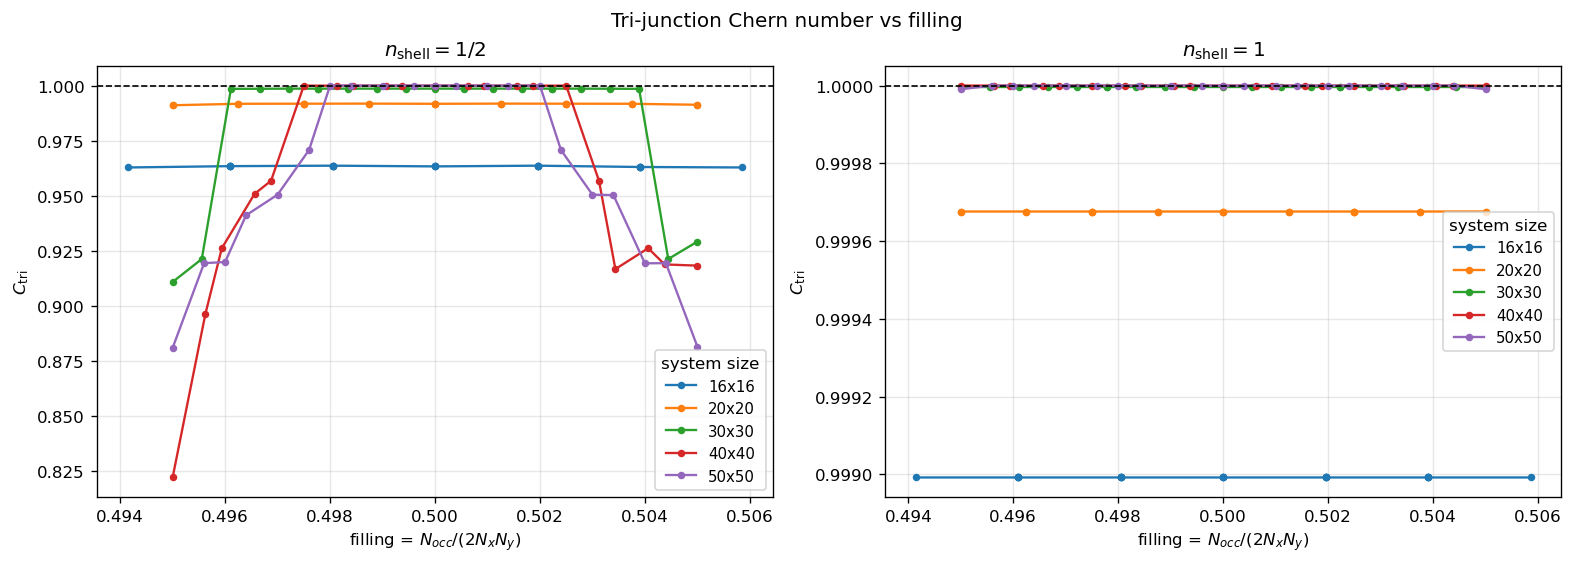

In [26]:
plot_chern_vs_filling(chern_df)


## `y_0` Spot Check

Before using the `y_0=0` shortcut for the entanglement calculation, check that the wrapped full-`x` strip entropy is effectively invariant under `y_0` for representative fillings and subsystem heights.


In [27]:
y0_invariance_df = pd.concat(
    [y0_spotcheck_rows(nx, ny) for nx, ny in ENT_SIZE_GRID],
    ignore_index=True,
)

spotcheck_summary_df = (
    y0_invariance_df
    .groupby(['Nx', 'Ny', 'nshell', 'shell_label'], dropna=False)['std_over_y0']
    .max()
    .reset_index(name='max_std_over_y0')
    .sort_values(['Nx', 'Ny', 'nshell'])
    .reset_index(drop=True)
)

print(f'y0_invariance_df shape = {y0_invariance_df.shape}')
spotcheck_summary_df


DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------


DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
y0_invariance_df shape = (66, 14)


,Nx,Ny,nshell,shell_label,max_std_over_y0
0,20,20,0.5,1/2,3.255778e-06
1,20,20,1.0,1,3.836550e-13
2,20,30,0.5,1/2,1.756334e-06
3,20,30,1.0,1,5.316330e-13
4,20,40,0.5,1/2,1.091563e-06
5,20,40,1.0,1,7.155933e-13
6,20,50,0.5,1/2,7.198722e-07
7,20,50,1.0,1,9.299430e-13


## Entanglement Slope vs Filling

Quasi-1D sweep with fixed `Nx=20` and `Ny in {20,30,40}`. One curve per `Ny`, one subplot per `nshell`.


In [28]:
slope_df = pd.concat(
    [slope_rows_for_geometry(nx, ny) for nx, ny in ENT_SIZE_GRID],
    ignore_index=True,
)

slope_report_df = slope_df[
    [
        'Nx',
        'Ny',
        'shell_label',
        'filling_percent_nominal',
        'filling_percent_actual',
        'filling_offset',
        'n_occ',
        'filling',
        'slope',
        'intercept',
        'r2',
    ]
].sort_values(['shell_label', 'Ny', 'filling_percent_nominal']).reset_index(drop=True)

print(f'slope_df shape = {slope_df.shape}')
slope_report_df


DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
DWs at x=(5, 15)
------------------------- classA_U1FGTN Initialized -------------------------
slope_df shape = (168, 14)


,Nx,Ny,shell_label,filling_percent_nominal,filling_percent_actual,filling_offset,n_occ,filling,slope,intercept,r2
0,20,20,1,-1.0,-1.00,-4,396,0.49500,0.333620,8.311019,1.000000
1,20,20,1,-0.9,-1.00,-4,396,0.49500,0.333620,8.311019,1.000000
2,20,20,1,-0.8,-0.75,-3,397,0.49625,0.333475,8.324501,1.000000
3,20,20,1,-0.7,-0.75,-3,397,0.49625,0.333475,8.324501,1.000000
4,20,20,1,-0.6,-0.50,-2,398,0.49750,0.333414,8.331369,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
163,20,50,1/2,0.6,0.60,6,1006,0.50300,0.333789,8.855853,1.000000
164,20,50,1/2,0.7,0.70,7,1007,0.50350,0.333949,8.852842,1.000000
165,20,50,1/2,0.8,0.80,8,1008,0.50400,0.334230,8.850466,1.000000
166,20,50,1/2,0.9,0.90,9,1009,0.50450,0.334510,8.848090,0.999999


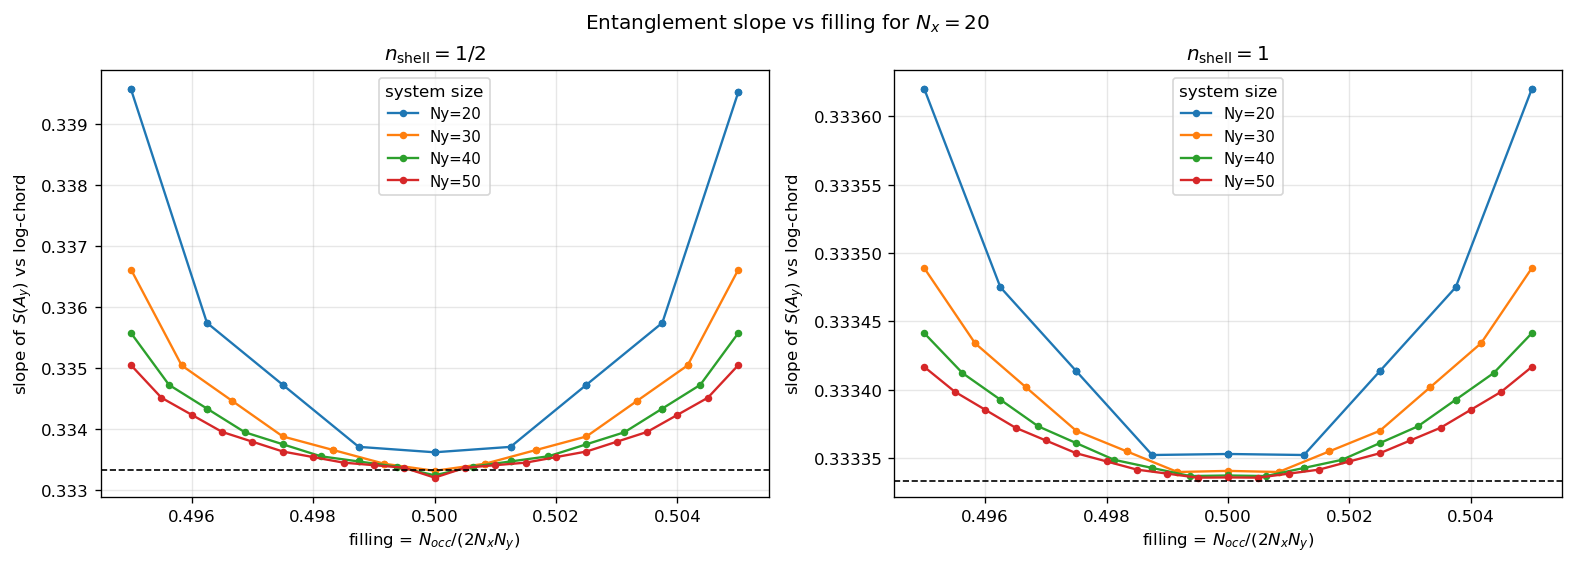

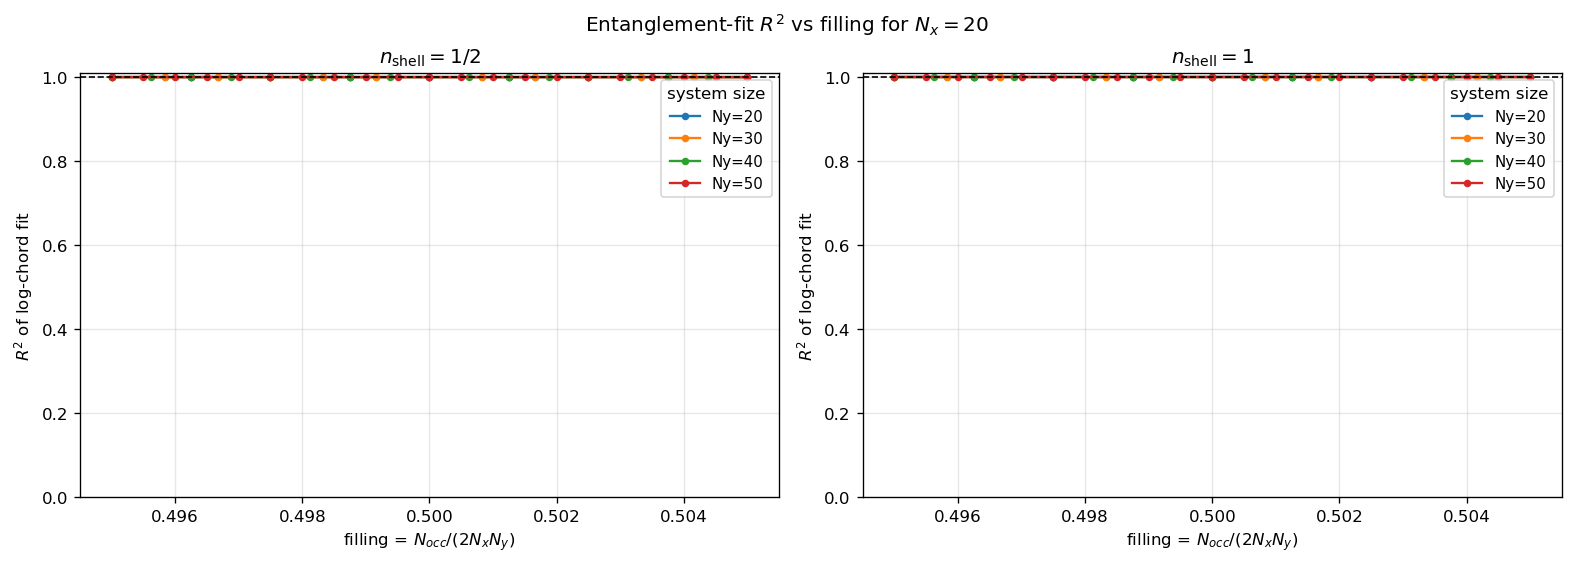

In [29]:
plot_slope_vs_filling(slope_df)
plot_r2_vs_filling(slope_df)


In [ ]:
# ── Entanglement slope vs system size (Ny) at fixed filling offsets ────────
# Averages over the ±filling_percent_nominal symmetric pair for each |percent|.
# Adjust SLOPE_VS_NY_PERCENTS to match available filling_percent_nominal values
# in slope_df (which come from np.linspace(-FILLING_PERCENT_WINDOW,
# FILLING_PERCENT_WINDOW, FILLING_SWEEP_STEPS)).

SLOPE_VS_NY_PERCENTS = [0.0, 0.5, 1.0, 2.0, 5.0]   # |filling offset| in %

Ny_values = sorted(slope_df['Ny'].unique())
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0.05, 0.95, len(SLOPE_VS_NY_PERCENTS)))

fig, axes = plt.subplots(1, len(NSHELL_VALUES), figsize=(13.0, 4.6), constrained_layout=True)
axes = np.atleast_1d(axes)

for ax, nshell in zip(axes, NSHELL_VALUES):
    shell_label = format_nshell(nshell)
    sub = slope_df[slope_df['nshell'] == nshell].copy()
    sub = sub.assign(abs_percent=sub['filling_percent_nominal'].abs())

    for color, target_pct in zip(colors, SLOPE_VS_NY_PERCENTS):
        slopes_by_ny = []
        for ny in Ny_values:
            ny_sub = sub[sub['Ny'] == ny]
            avail = ny_sub['abs_percent'].unique()
            nearest = avail[np.argmin(np.abs(avail - target_pct))]
            matched = ny_sub[np.isclose(ny_sub['abs_percent'], nearest)]
            slopes_by_ny.append((int(ny), float(matched['slope'].mean())))
        ny_arr, slope_arr = zip(*slopes_by_ny)
        label = 'half-filling' if np.isclose(target_pct, 0.0) else f'{target_pct:.1f}%'
        ax.plot(ny_arr, slope_arr, marker='o', ms=5, lw=1.5, color=color, label=label)

    ax.axhline(1.0 / 3.0, color='black', ls='--', lw=1.0, alpha=0.7, label='1/3 reference')
    ax.set_title(rf'$n_{{\mathrm{{shell}}}}={shell_label}$')
    ax.set_xlabel('$N_y$')
    ax.set_ylabel(r'slope of $S(A_y)$ vs log-chord')
    ax.set_xticks(Ny_values)
    ax.grid(alpha=0.3)
    ax.legend(title='|filling offset|', fontsize=9)

fig.suptitle(
    r'Entanglement slope vs system size $N_y$ at fixed filling offsets  ($N_x=20$)',
    fontsize=13,
)
plt.show()


In [30]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
chern_path = DATA_DIR / 'flattened_hamiltonian_finite_size_chern_vs_filling.csv'
slope_path = DATA_DIR / 'flattened_hamiltonian_finite_size_slope_vs_filling.csv'

chern_df.to_csv(chern_path, index=False)
slope_df.to_csv(slope_path, index=False)

print(f'Saved Chern data to {chern_path}')
print(f'Saved slope data to {slope_path}')


Saved Chern data to /home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/flattened_hamiltonian_analysis/data/flattened_hamiltonian_finite_size_chern_vs_filling.csv
Saved slope data to /home/abhuiyan/class_A_fermionic_adaptive_circuit/notebooks/flattened_hamiltonian_analysis/data/flattened_hamiltonian_finite_size_slope_vs_filling.csv
